In [58]:
#imports
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from tqdm import tqdm

In [59]:
#loading data from google drive
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [60]:
#organizing files
data_folder= "/content/drive/MyDrive/Colab Notebooks/wildfire"

train_files = sorted(glob.glob(data_folder +"/*train*.tfrecord"))
val_files= sorted(glob.glob(data_folder + "/*eval*.tfrecord"))
testFiles =sorted(glob.glob(data_folder+ "/*test*.tfrecord"))

print("Train",len(train_files))
print("validation",len(val_files))
print("test",len(testFiles))

Train 15
validation 2
test 2


In [61]:
#data check
eda.isnull().sum().sort_values(ascending=False)
eda.isnull().sum().sum()

np.int64(0)

In [62]:
#features
all_features = [
    'NDVI',
    'tmmn',
    'elevation',
    'population',
    'FireMask',
    'vs',
    'pdsi',
    'pr',
    'tmmx',
    'sph',
    'th',
    'PrevFireMask',
    'erc']
input_feats = [
    'NDVI',
    'tmmn',
    'elevation',
    'population',
    'vs',
    'pdsi',
    'pr',
    'tmmx',
    'sph',
    'th',
    'PrevFireMask',
    'erc']

feature_dict = {}
for f in all_features:
    feature_dict[f] = tf.io.FixedLenFeature([4096], tf.float32)
def read_tfrecord(example):

    ex = tf.io.parse_single_example(
        example,
        feature_dict)

    for c in all_features:
        ex[c] =tf.reshape(ex[c],[64,64])

    x =tf.stack(
        [ex[c] for c in input_feats],
        axis=-1)

    y= tf.expand_dims(
        ex['FireMask'],
        axis=-1)
    return x,y

In [63]:
#dataset creation
train_raw= tf.data.TFRecordDataset(train_files)
val_raw =tf.data.TFRecordDataset(val_files)
test_raw= tf.data.TFRecordDataset(testFiles)

train_ds = train_raw.map(read_tfrecord)
val_ds =val_raw.map(read_tfrecord)
test_ds =test_raw.map(read_tfrecord)

for x1,y1 in train_ds.take(1):
    print(x1.shape)
    print(y1.shape)

(64, 64, 12)
(64, 64, 1)


In [64]:
ntrain= 0
for i in tf.data.TFRecordDataset(train_files):
    ntrain += 1

nval= 0
for i in tf.data.TFRecordDataset(val_files):
    nval += 1

ntest =0
for i in tf.data.TFRecordDataset(testFiles):
    ntest += 1

print("Train",ntrain)
print("validation",nval)
print("test",ntest)

Train 14979
validation 1877
test 1689


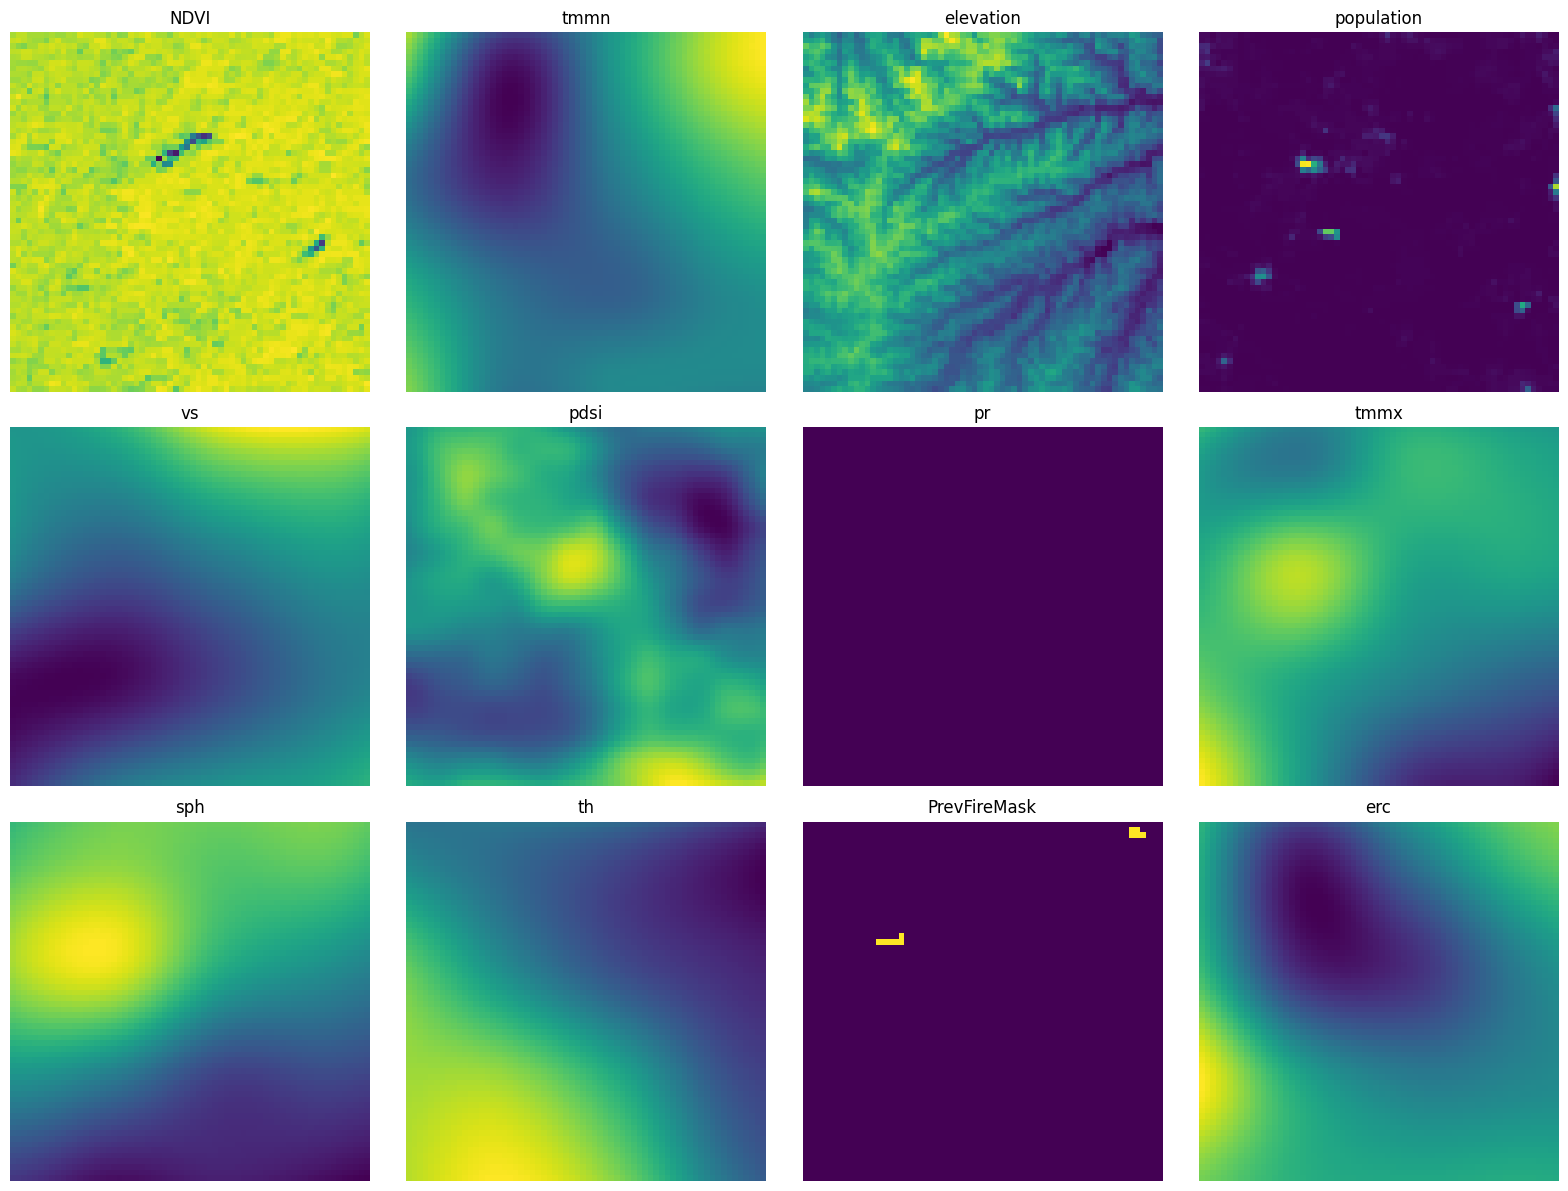

In [65]:
for xx,yy in train_ds.take(1):
    xx = xx.numpy()
    yy = yy.numpy()

fig,ax = plt.subplots(3,4,figsize=(16,12))
ax = ax.flatten()

for i in range(len(input_feats)):
    pic = ax[i].imshow(
        xx[:,:,i],
        cmap="viridis")

    ax[i].set_title(input_feats[i])
    ax[i].axis("off")
plt.tight_layout()
plt.show()

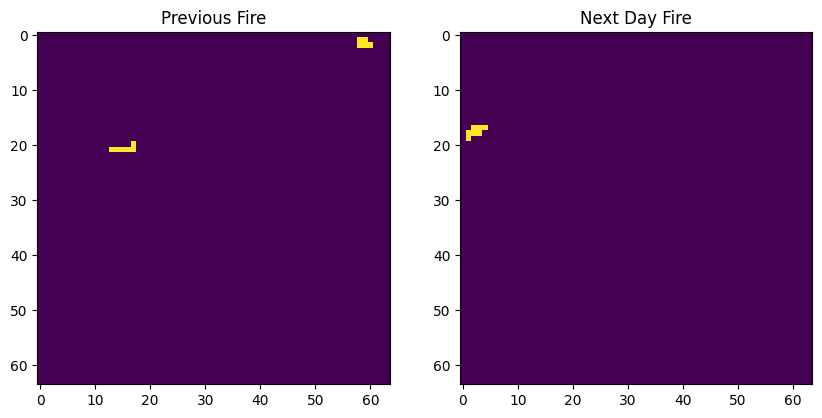

In [66]:
prev_ind =input_feats.index("PrevFireMask")
fig,axs= plt.subplots(1,2,figsize=(10,5))
axs[0].imshow(xx[:,:,prev_ind])
axs[0].set_title("Previous Fire")
axs[1].imshow(yy[:,:,0])
axs[1].set_title("Next Day Fire")
plt.show()

In [67]:
#eda
big_list= []
for x,y in tqdm(train_ds.take(3000)):
    x =x.numpy()
    y= y.numpy()
    row ={}
    for i in range(len(input_feats)):

        row[input_feats[i]+"_mean"]= np.mean(
            x[:,:,i])

        row[input_feats[i]+"_std"]= np.std(
            x[:,:,i])

    row["fire_mean"]= np.mean(y[:,:,0])
    row["fire_pixels"] =np.sum(y[:,:,0])

    big_list.append(row)
eda =pd.DataFrame(big_list)
eda.head()

3000it [00:04, 704.50it/s]


,NDVI_mean,NDVI_std,tmmn_mean,tmmn_std,elevation_mean,elevation_std,population_mean,population_std,vs_mean,vs_std,...,sph_mean,sph_std,th_mean,th_std,PrevFireMask_mean,PrevFireMask_std,erc_mean,erc_std,fire_mean,fire_pixels
0,7520.236328,670.652649,275.738495,0.266695,85.027588,19.802109,8.426208,34.163864,3.028638,0.108443,...,0.004588,0.000092,174.233856,8.146731,0.002686,0.051753,20.463581,1.038277,0.001709,7.0
1,7520.236328,670.652649,276.451965,0.183867,85.027588,19.802109,8.426208,34.163864,2.918974,0.173904,...,0.005194,0.000087,293.806824,13.990176,0.001221,0.034917,23.228920,1.004710,0.000000,0.0
2,8454.343750,629.416626,294.328735,0.179653,85.027588,19.802109,8.426208,34.163864,3.518163,0.150270,...,0.016385,0.000249,80.197083,18.898401,0.004150,0.064290,20.090822,2.199933,0.001709,7.0
3,6057.905273,1524.526978,285.614105,0.475977,108.591553,15.285831,18.248913,83.417732,3.909244,0.188053,...,0.009392,0.000135,268.048004,2.131541,0.000732,0.027053,25.684216,1.217350,0.000000,0.0
4,6653.063477,1177.312012,275.862122,0.485526,108.591553,15.285831,18.248913,83.417732,4.179440,0.116634,...,0.005647,0.000214,106.072441,4.422122,0.001709,0.041305,25.363003,1.344022,0.001221,5.0


In [68]:
#eda.isnull().sum()
eda.describe().T

,count,mean,std,min,25%,50%,75%,max
NDVI_mean,3000.0,5296.457520,1622.509277,657.382812,4158.287109,5196.654785,6483.219238,8716.274414
NDVI_std,3000.0,1330.279053,587.801270,211.860214,918.010193,1288.294373,1601.665863,5489.196289
tmmn_mean,3000.0,282.604462,8.955791,203.071655,278.710487,283.675064,287.940727,299.476868
tmmn_std,3000.0,3.155088,13.639712,0.054639,0.420640,0.788416,1.320705,127.030754
elevation_mean,3000.0,985.900940,823.931580,1.414551,189.902588,848.410522,1669.167725,3328.058350
elevation_std,3000.0,215.068939,186.373688,1.042570,25.712936,232.734756,351.917900,922.424561
population_mean,3000.0,25.375753,81.283920,0.000390,1.079959,5.988832,18.924396,1150.462769
population_std,3000.0,88.237045,149.471115,0.003362,9.455989,37.377047,97.271570,2268.442383
vs_mean,3000.0,3.598737,1.195804,1.005705,2.758251,3.376803,4.264531,9.311747
vs_std,3000.0,0.298459,0.271378,0.020913,0.135968,0.226987,0.366449,2.775764


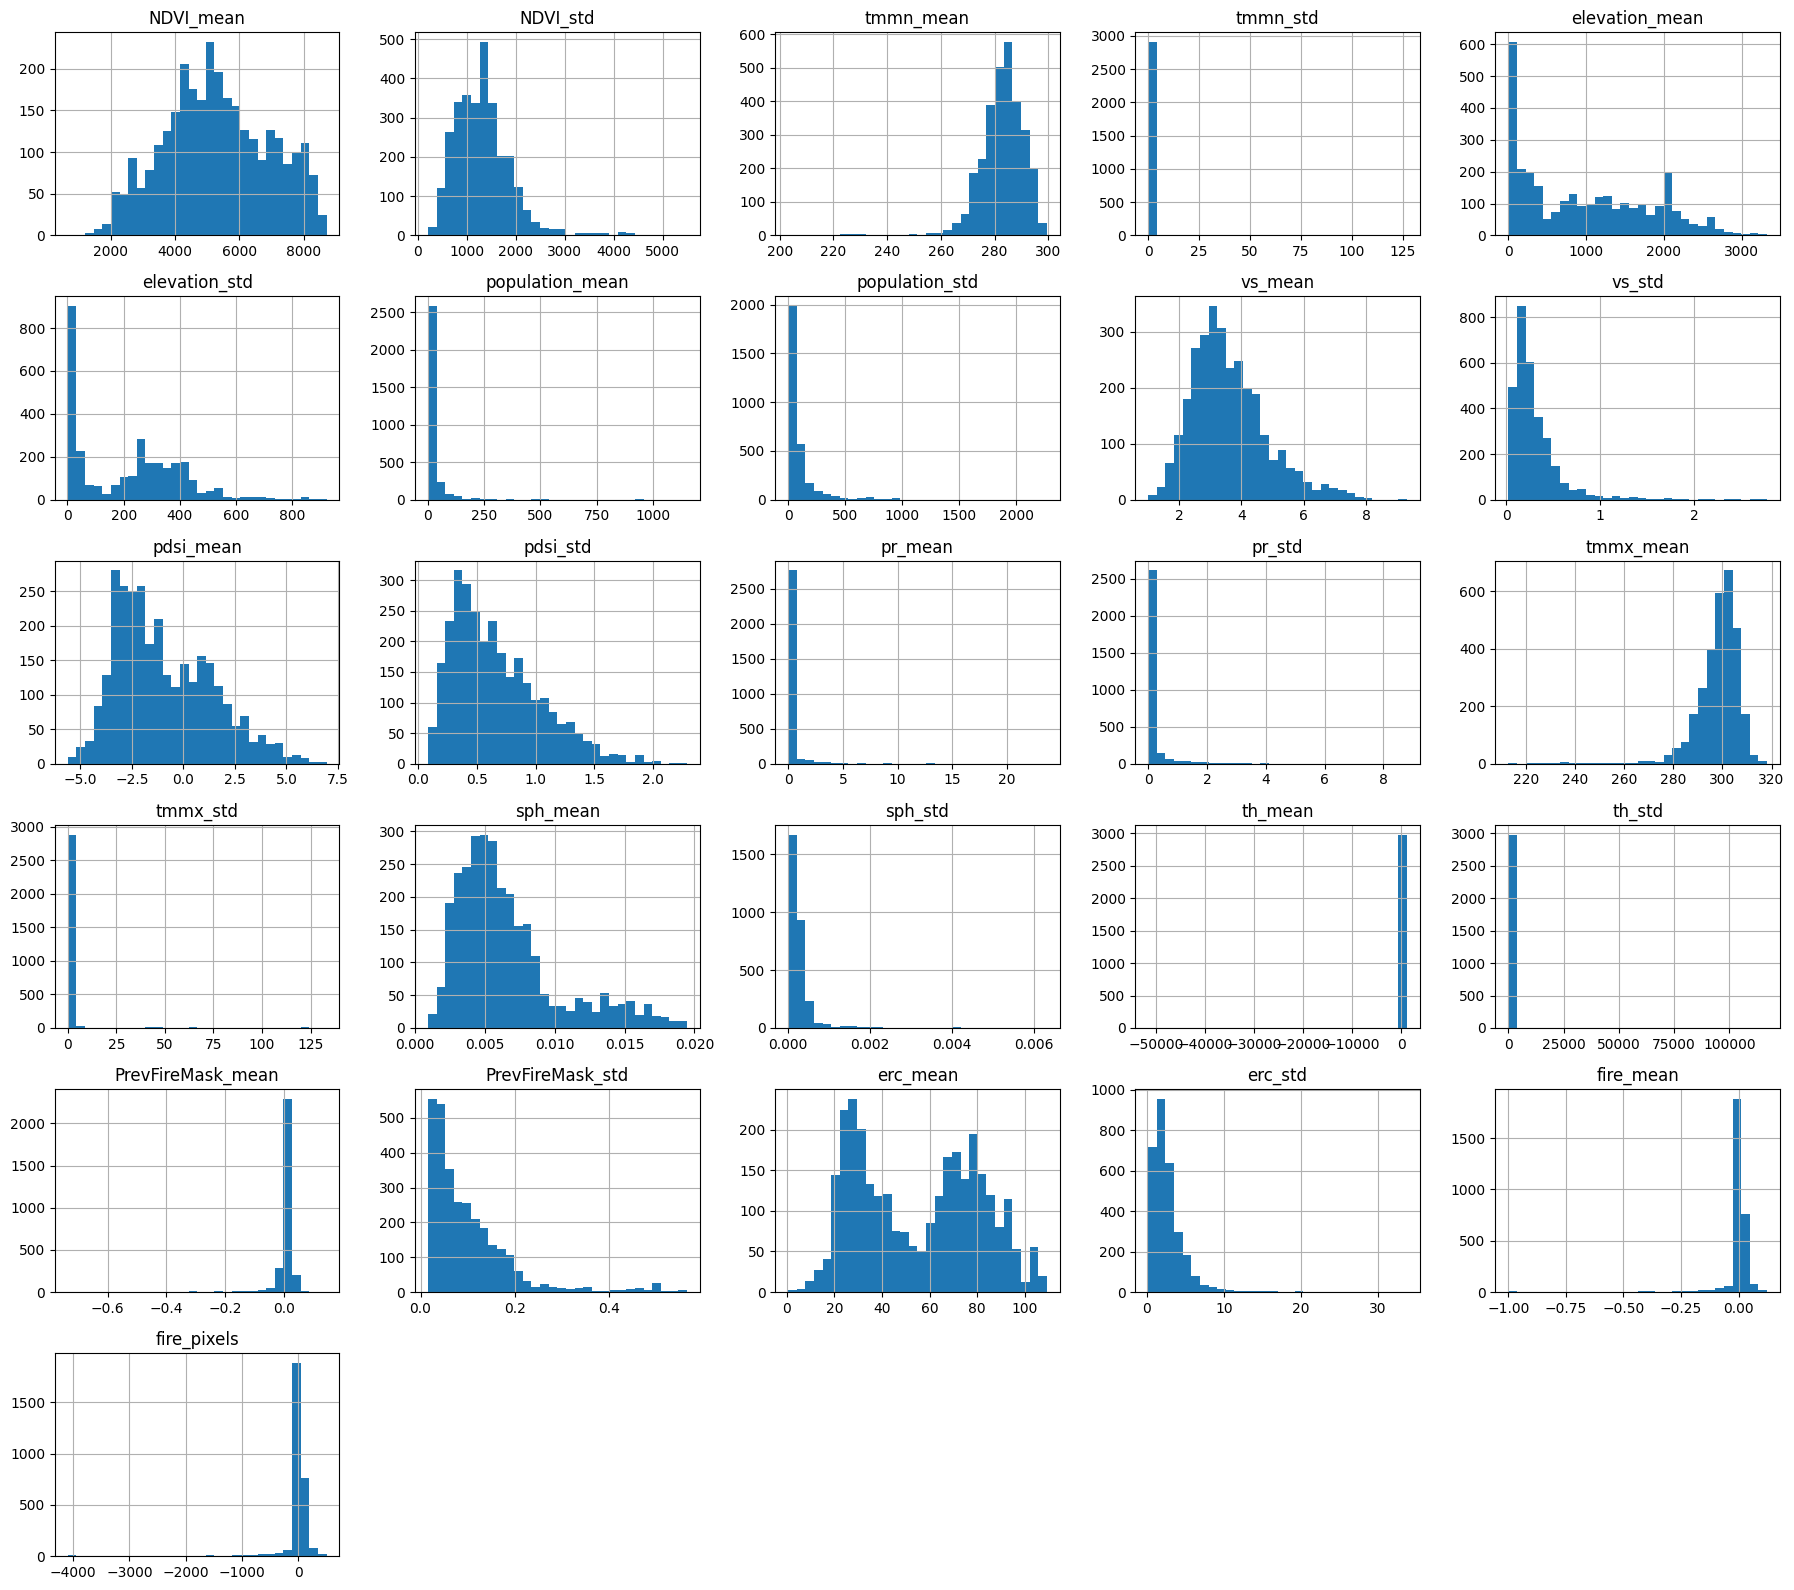

In [69]:
eda.hist(
figsize=(18,16),
bins=30)

plt.tight_layout()
plt.show()

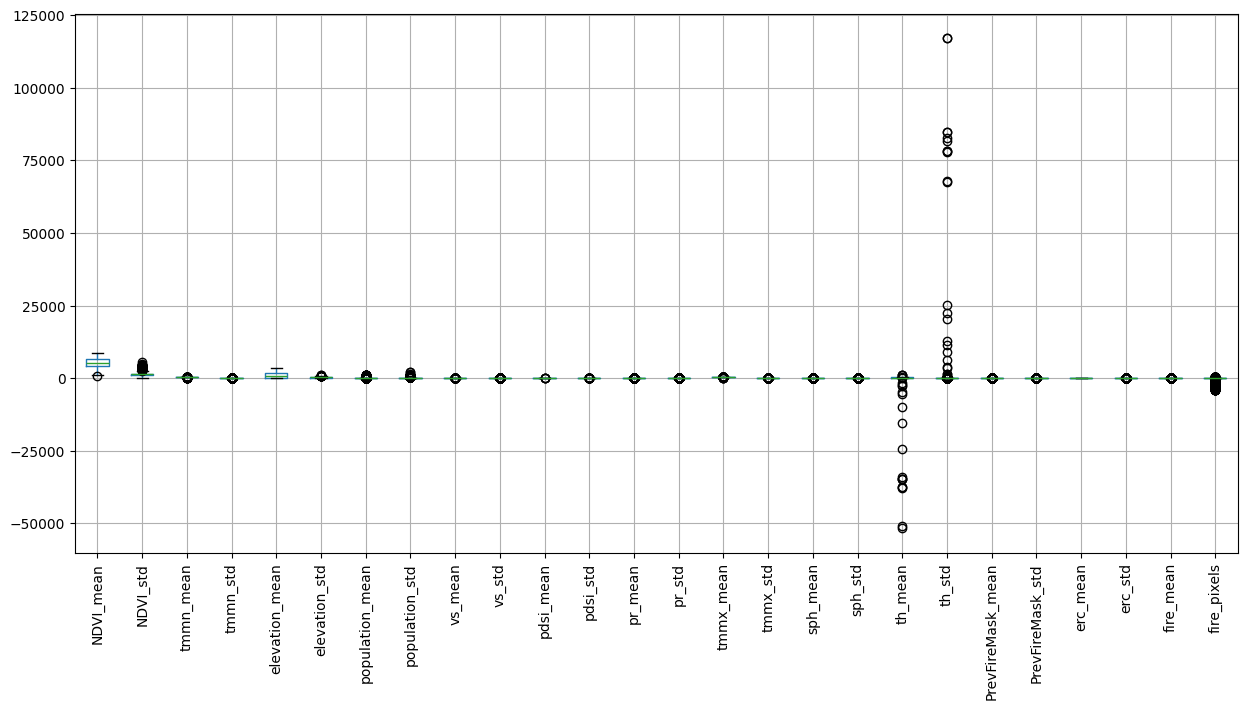

In [70]:
plt.figure(figsize=(15,7))
eda.boxplot(rot=90)
plt.show()

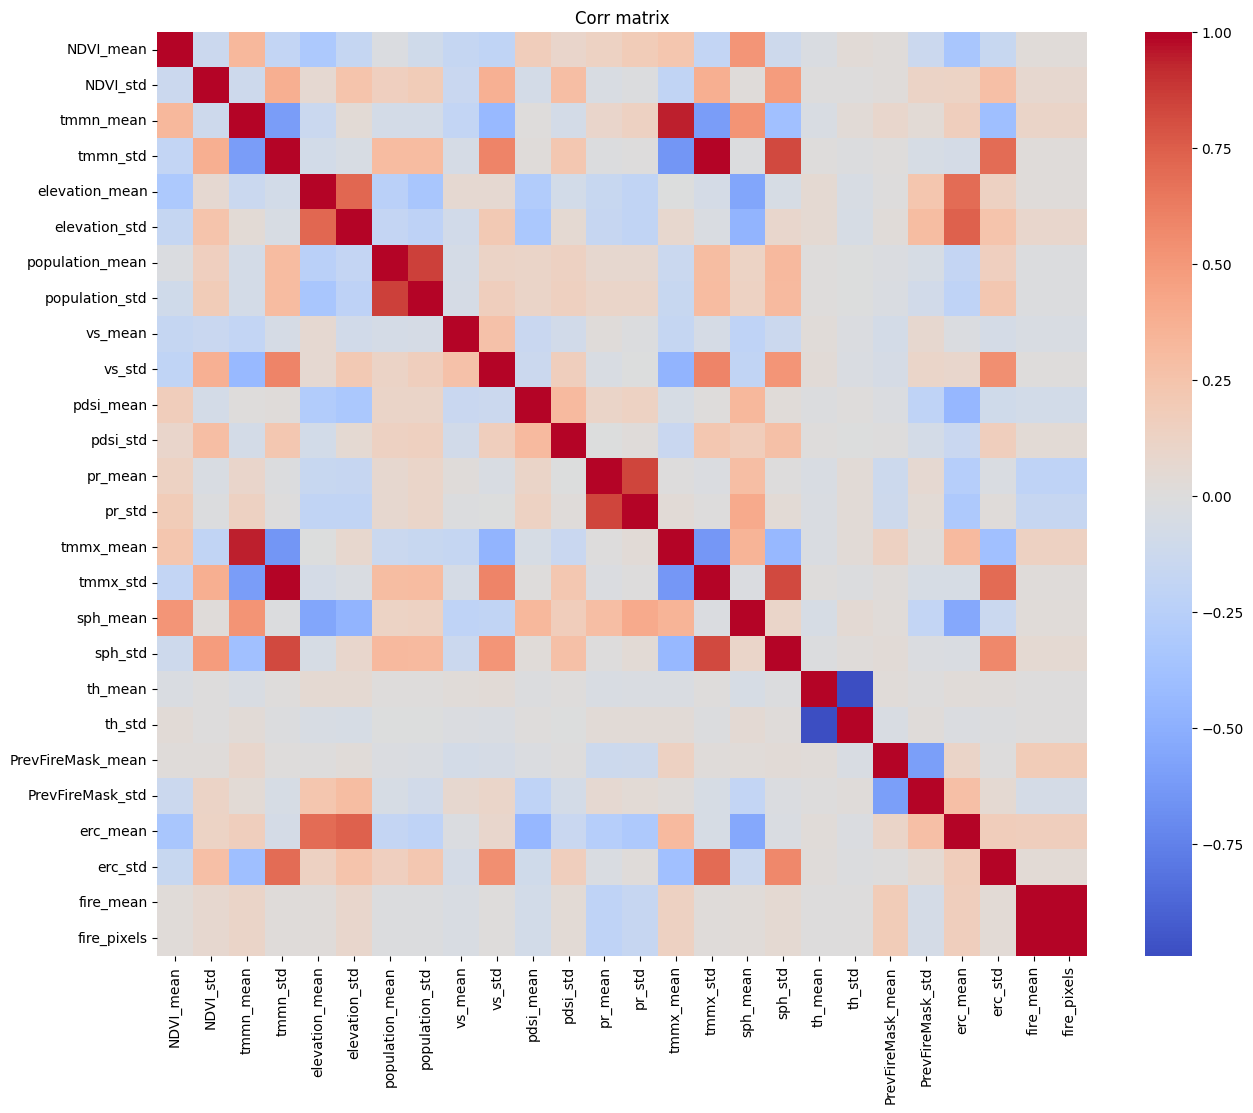

In [71]:
corrs = eda.corr()
plt.figure(figsize=(15,12))

sns.heatmap(corrs,cmap="coolwarm", center=0)
plt.title("Corr matrix")
plt.show()

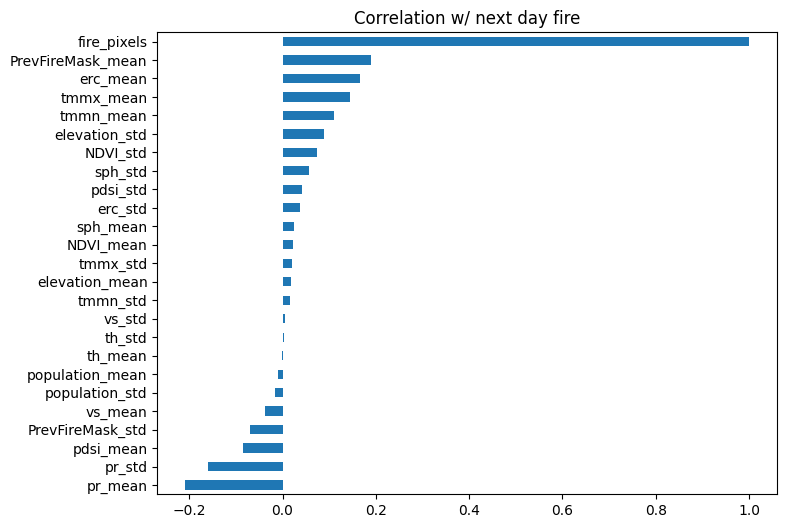

In [72]:
#fire_corr = corrs["fire_mean"]
#fire_corr.sort_values()
fire_corr.drop("fire_mean").sort_values().plot(kind="barh",figsize=(8,6))
plt.title("Correlation w/ next day fire")
plt.show()

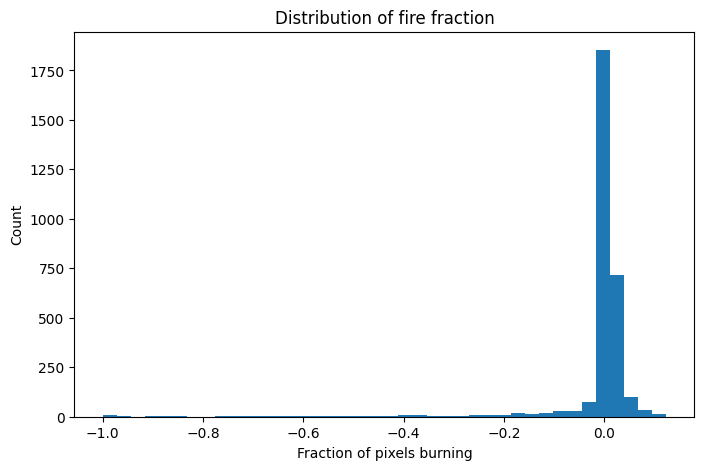

In [73]:
plt.figure(figsize=(8,5))

plt.hist(eda["fire_mean"],bins=40)
plt.xlabel("Fraction of pixels burning")
plt.ylabel("Count")
plt.title("Distribution of fire fraction")
plt.show()

In [74]:
out_list = []
for c in eda.columns:
    q1 = eda[c].quantile(.25)
    q3 = eda[c].quantile(.75)
    iqr = q3-q1

    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr

    n = (
        (eda[c] < low)
        |
        (eda[c] > high)).sum()

    out_list.append([c,n])

out_df = pd.DataFrame(out_list,columns=["feature","outliers"])
out_df.sort_values(
    "outliers",
    ascending=False)

,feature,outliers
12,pr_mean,635
13,pr_std,567
20,PrevFireMask_mean,537
25,fire_pixels,523
24,fire_mean,523
6,population_mean,366
7,population_std,274
19,th_std,259
16,sph_mean,226
3,tmmn_std,220


In [75]:
#eda.skew().sort_values()

In [76]:
#saving 4 later
eda.to_csv( "wildfire_eda.csv",index=False)
out_df.to_csv("wildfire_outliers.csv",index=False)